Initial Shape: (7043, 21)
Cleaned Shape: (7043, 22)


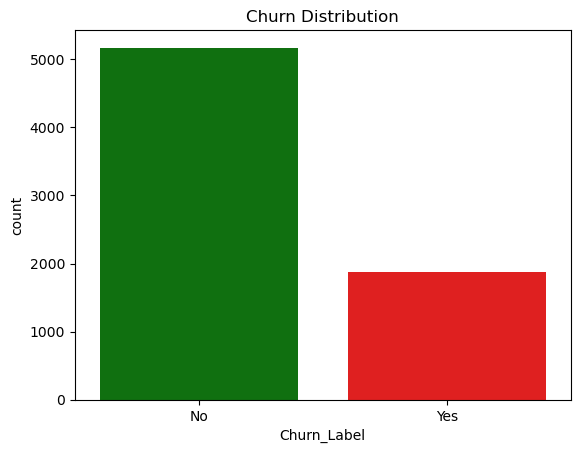

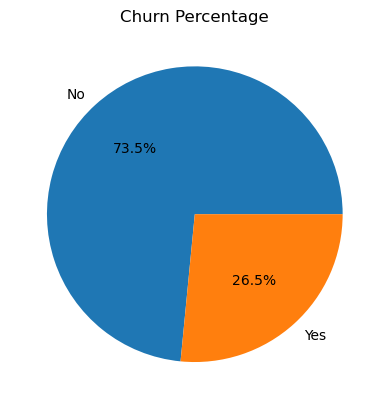

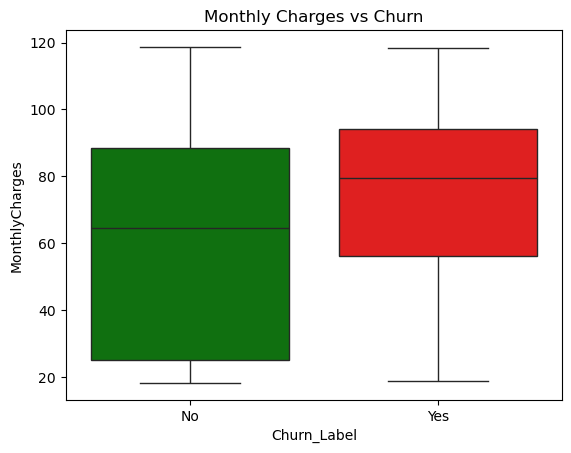

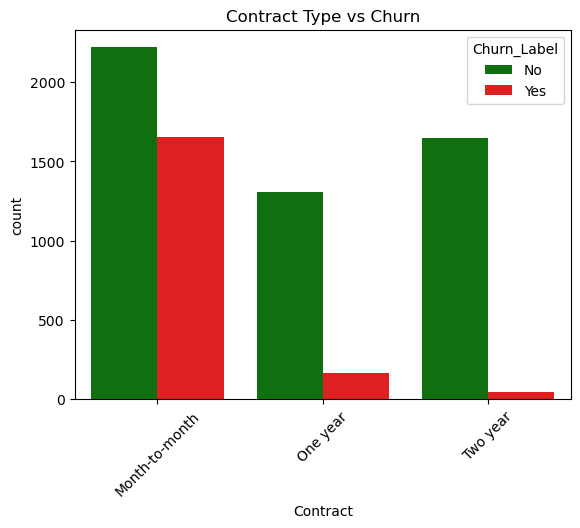

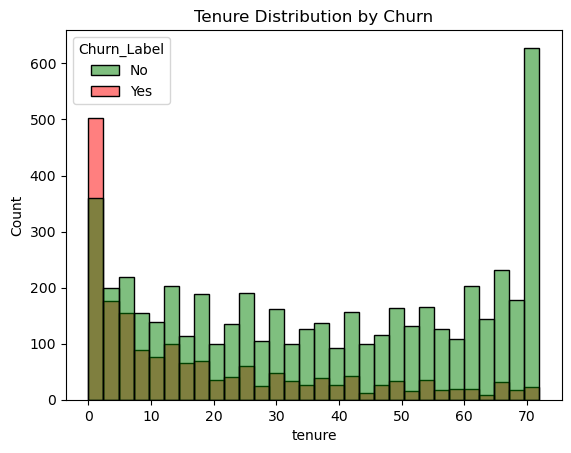

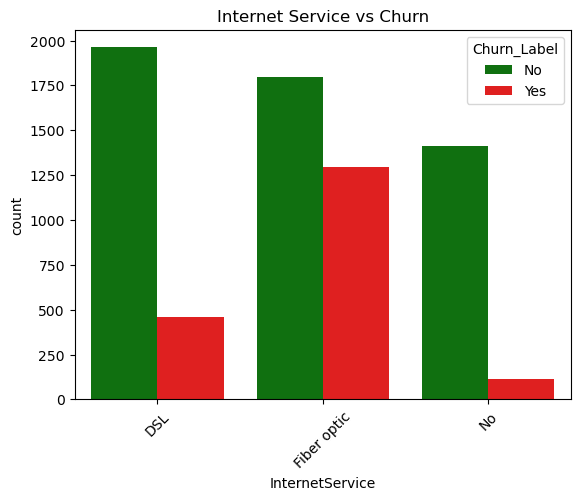

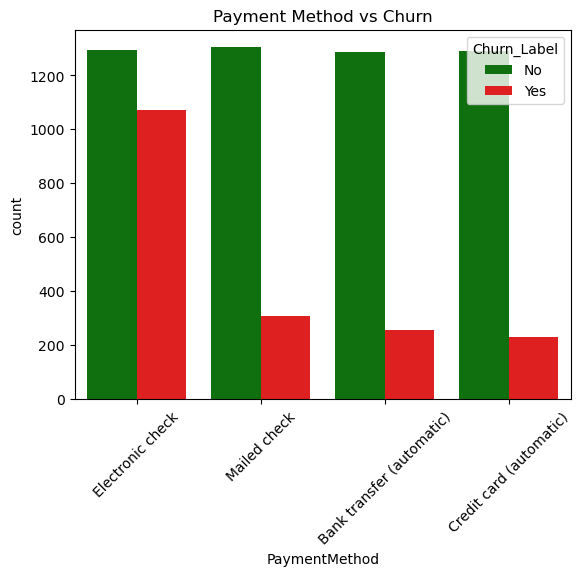

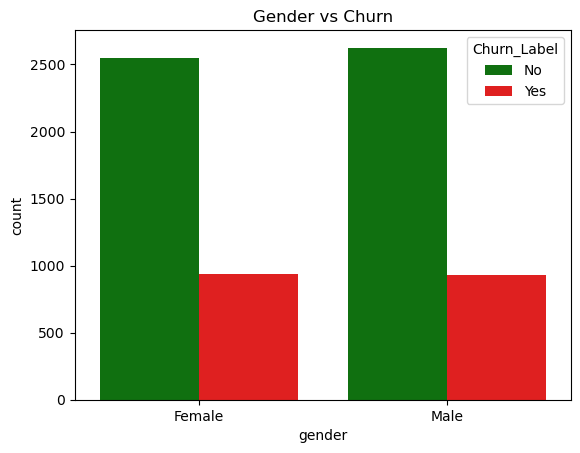

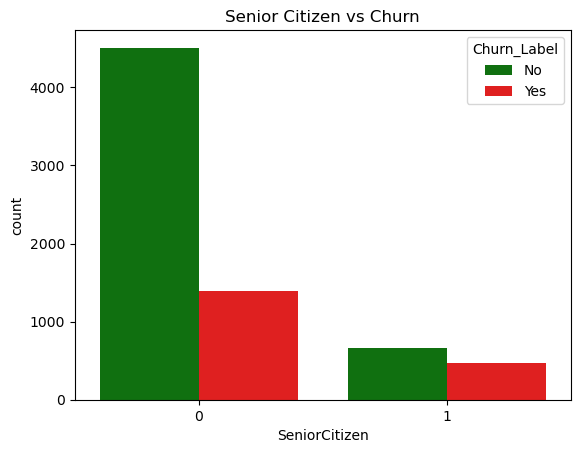

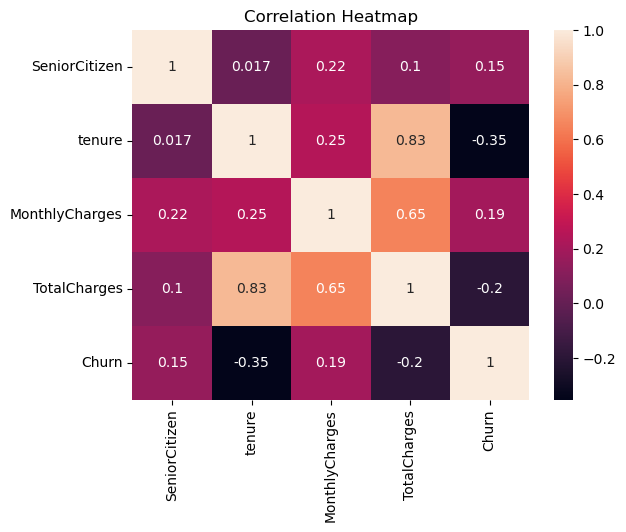


===== INSIGHTS =====

Total Customers: 7043
Overall Churn Rate: 26.54%

--- Key Findings ---

1. Customers with higher monthly charges are more likely to churn.
   Avg Monthly Charges (Churned): 74.44
   Avg Monthly Charges (Stayed): 61.27

2. Contract Type Impact:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858

3. Customers with lower tenure are more likely to churn.
   Avg Tenure (Churned): 17.98
   Avg Tenure (Stayed): 37.57

4. Month-to-month contracts have the highest churn rate.

--- Business Recommendations ---

- Focus on retaining new customers in the first few months.
- Encourage long-term contracts with discounts.
- Provide targeted offers for high monthly charge users.


All outputs saved in: F:\OUTRIX Data\Tele-Cus-churn_outputs


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


output_folder = r"F:\OUTRIX Data\Tele-Cus-churn_outputs"
os.makedirs(output_folder, exist_ok=True)


file_path = r"F:\OUTRIX Data\WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

print("Initial Shape:", df.shape)


# Data Cleaning

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fix missing values (no warning)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert Churn to numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Create readable labels
df['Churn_Label'] = df['Churn'].map({0: 'No', 1: 'Yes'})

print("Cleaned Shape:", df.shape)


# Save Cleaned Data

df.to_csv(os.path.join(output_folder, "cleaned_churn.csv"), index=False)


# ANALYSIS

churn_rate = df['Churn'].mean() * 100
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
charges_churn = df.groupby('Churn')['MonthlyCharges'].mean()
tenure_churn = df.groupby('Churn')['tenure'].mean()


# VISUAL SETTINGS

palette = {'No': 'green', 'Yes': 'red'}


# VISUALIZATIONS

# 1. Churn Distribution
plt.figure()
sns.countplot(
    x='Churn_Label',
    hue='Churn_Label',
    data=df,
    palette=palette,
    legend=False
)
plt.title("Churn Distribution")
plt.savefig(os.path.join(output_folder, "churn_distribution.png"))
plt.show()

# 2. Pie Chart
plt.figure()
df['Churn_Label'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Churn Percentage")
plt.ylabel('')
plt.savefig(os.path.join(output_folder, "churn_pie.png"))
plt.show()

# 3. Monthly Charges vs Churn (FIXED)
plt.figure()
sns.boxplot(
    x='Churn_Label',
    y='MonthlyCharges',
    hue='Churn_Label',
    data=df,
    palette=palette,
    legend=False
)
plt.title("Monthly Charges vs Churn")
plt.savefig(os.path.join(output_folder, "monthly_charges_vs_churn.png"))
plt.show()

# 4. Contract Type vs Churn
plt.figure()
sns.countplot(
    x='Contract',
    hue='Churn_Label',
    data=df,
    palette=palette
)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=45)
plt.savefig(os.path.join(output_folder, "contract_vs_churn.png"))
plt.show()

# 5. Tenure vs Churn
plt.figure()
sns.histplot(
    data=df,
    x='tenure',
    hue='Churn_Label',
    bins=30,
    palette=palette
)
plt.title("Tenure Distribution by Churn")
plt.savefig(os.path.join(output_folder, "tenure_vs_churn.png"))
plt.show()

# 6. Internet Service vs Churn
plt.figure()
sns.countplot(
    x='InternetService',
    hue='Churn_Label',
    data=df,
    palette=palette
)
plt.title("Internet Service vs Churn")
plt.xticks(rotation=45)
plt.savefig(os.path.join(output_folder, "internet_vs_churn.png"))
plt.show()

# 7. Payment Method vs Churn
plt.figure()
sns.countplot(
    x='PaymentMethod',
    hue='Churn_Label',
    data=df,
    palette=palette
)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.savefig(os.path.join(output_folder, "payment_vs_churn.png"))
plt.show()

# 8. Gender vs Churn
plt.figure()
sns.countplot(
    x='gender',
    hue='Churn_Label',
    data=df,
    palette=palette
)
plt.title("Gender vs Churn")
plt.savefig(os.path.join(output_folder, "gender_vs_churn.png"))
plt.show()

# 9. Senior Citizen vs Churn
plt.figure()
sns.countplot(
    x='SeniorCitizen',
    hue='Churn_Label',
    data=df,
    palette=palette
)
plt.title("Senior Citizen vs Churn")
plt.savefig(os.path.join(output_folder, "senior_vs_churn.png"))
plt.show()

# 10. Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.savefig(os.path.join(output_folder, "correlation_heatmap.png"))
plt.show()


# SUMMARY TABLE

summary = df.groupby('Churn_Label').agg({
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean'
})
summary.to_csv(os.path.join(output_folder, "summary_stats.csv"))


# INSIGHTS

insights = f"""
Total Customers: {len(df)}
Overall Churn Rate: {churn_rate:.2f}%

--- Key Findings ---

1. Customers with higher monthly charges are more likely to churn.
   Avg Monthly Charges (Churned): {charges_churn[1]:.2f}
   Avg Monthly Charges (Stayed): {charges_churn[0]:.2f}

2. Contract Type Impact:
{contract_churn.to_string()}

3. Customers with lower tenure are more likely to churn.
   Avg Tenure (Churned): {tenure_churn[1]:.2f}
   Avg Tenure (Stayed): {tenure_churn[0]:.2f}

4. Month-to-month contracts have the highest churn rate.

--- Business Recommendations ---

- Focus on retaining new customers in the first few months.
- Encourage long-term contracts with discounts.
- Provide targeted offers for high monthly charge users.
"""

print("\n===== INSIGHTS =====")
print(insights)

# Save insights
with open(os.path.join(output_folder, "insights.txt"), "w") as f:
    f.write(insights)

print(f"\nAll outputs saved in: {output_folder}")